In [1]:
%load_ext autoreload
%autoreload 2
from Network import Network, Layer
import torch
import random
import matplotlib.pyplot as plt



In [2]:
inputs = torch.tensor([[0.0,0.0], [0.,1.], [1.,0.], [1., 1.]])
outputs = torch.tensor([0, 1, 1, 0])

In [3]:
# SGD - only use one input
xor_network = Network()
xor_network.layers.append(Layer(2, 4))
xor_network.layers.append(Layer(4, 2, activation_function=torch.nn.Identity()))
mse_errors=[]
for i in range(1000):
    j = random.randint(0,3)
    xor_network.calculate_with_gradient(inputs[j].unsqueeze(0), outputs[j].unsqueeze(0), momentum =0.99)
    xor_network.update_weights(0.001)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9943, 0.0057]])
tensor([[0.0021, 0.9979]])
tensor([[0.0071, 0.9929]])
tensor([[0.9961, 0.0039]])


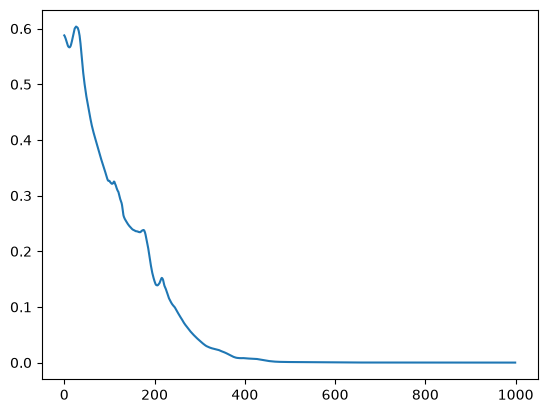

In [4]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

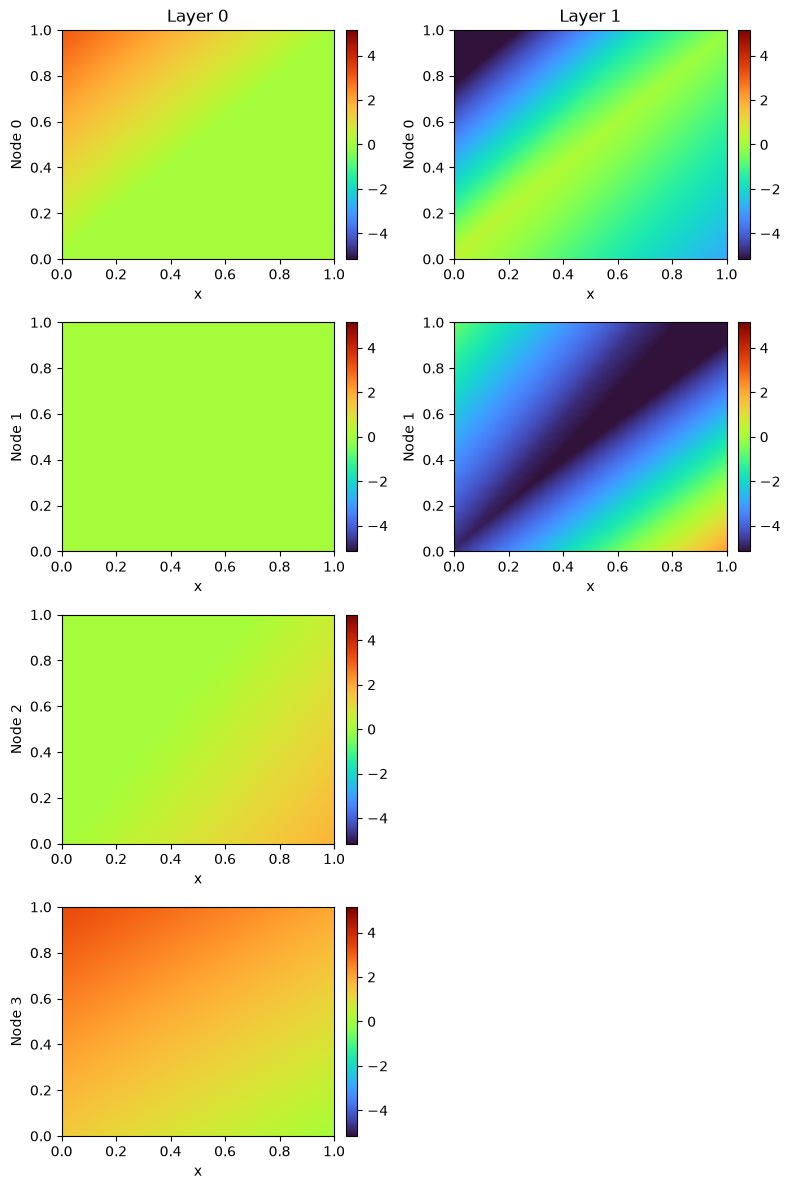

In [5]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [6]:
# Same as above but for sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2, 4, torch.sigmoid))
#xor_network.layers.append(Layer(4, 4, torch.sigmoid))
xor_network.layers.append(Layer(4, 2, torch.nn.Identity()))

mse_errors=[]
for i in range(800):
    for j in random.choices([0, 1, 2, 3], k=1):
        xor_network.calculate_with_gradient(inputs[j].unsqueeze(0), outputs[j].unsqueeze(0), momentum=0.99)
    
    xor_network.update_weights(0.04)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.8405, 0.1595]])
tensor([[0.8198, 0.1802]])
tensor([[7.7335e-06, 9.9999e-01]])
tensor([[0.8186, 0.1814]])


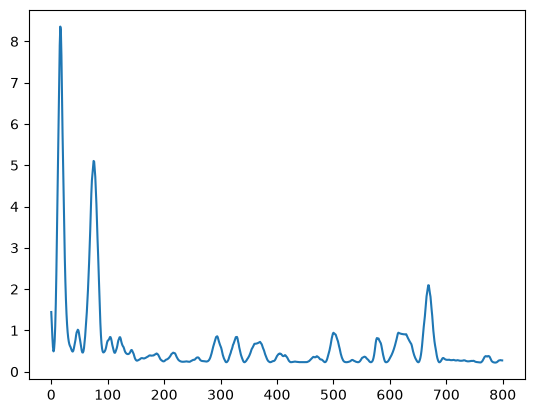

In [7]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

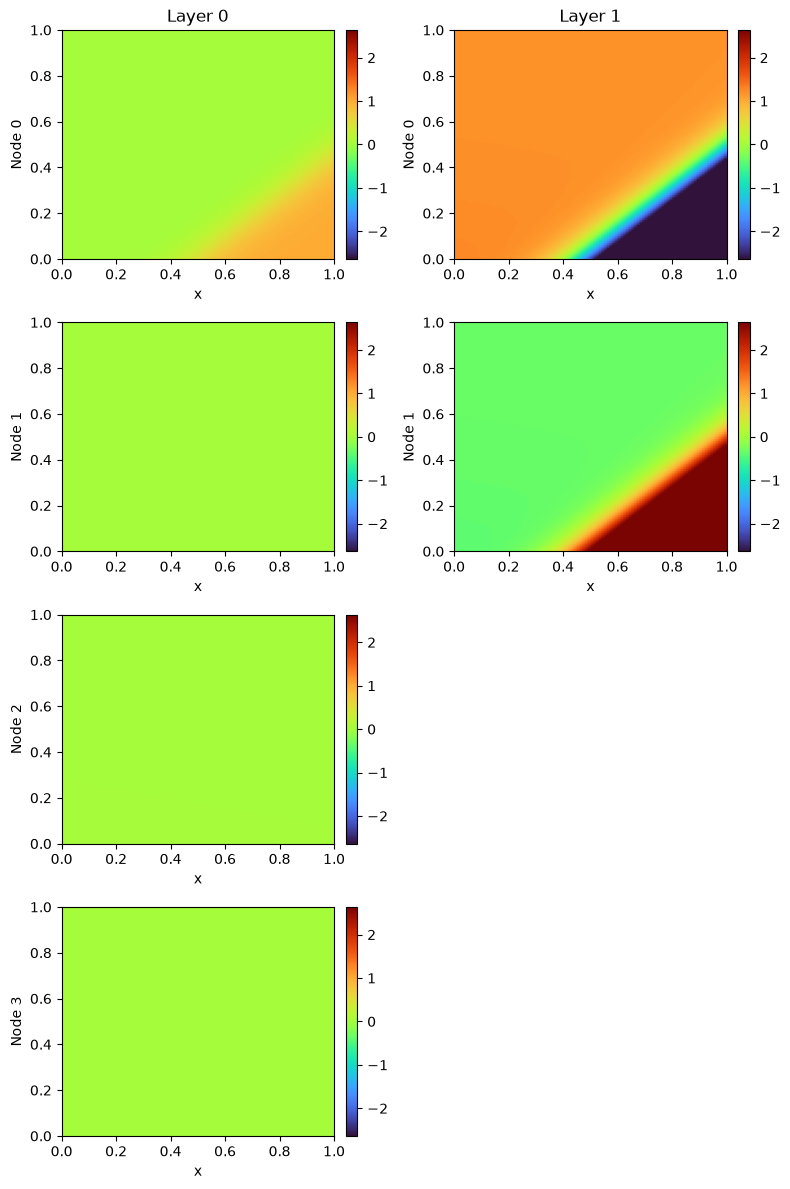

In [8]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [9]:
# Full gradient descent
xor_network = Network()
xor_network.layers.append(Layer(2,4))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))

mse_errors=[]
for i in range(1000):
    xor_network.calculate_with_gradient(inputs, outputs, momentum=0.999)

    xor_network.update_weights(0.01)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.5454, 0.4546]])
tensor([[0., 1.]])
tensor([[0.5454, 0.4546]])
tensor([[1.0000e+00, 1.8626e-30]])


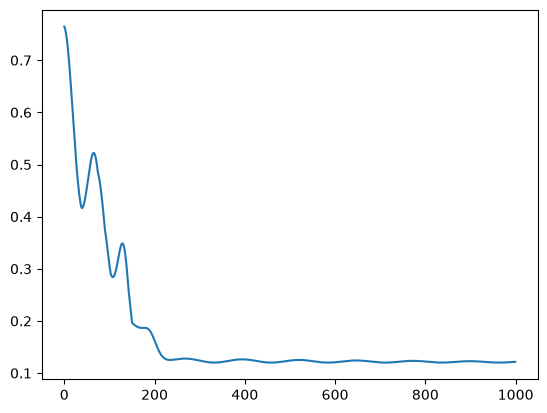

In [10]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

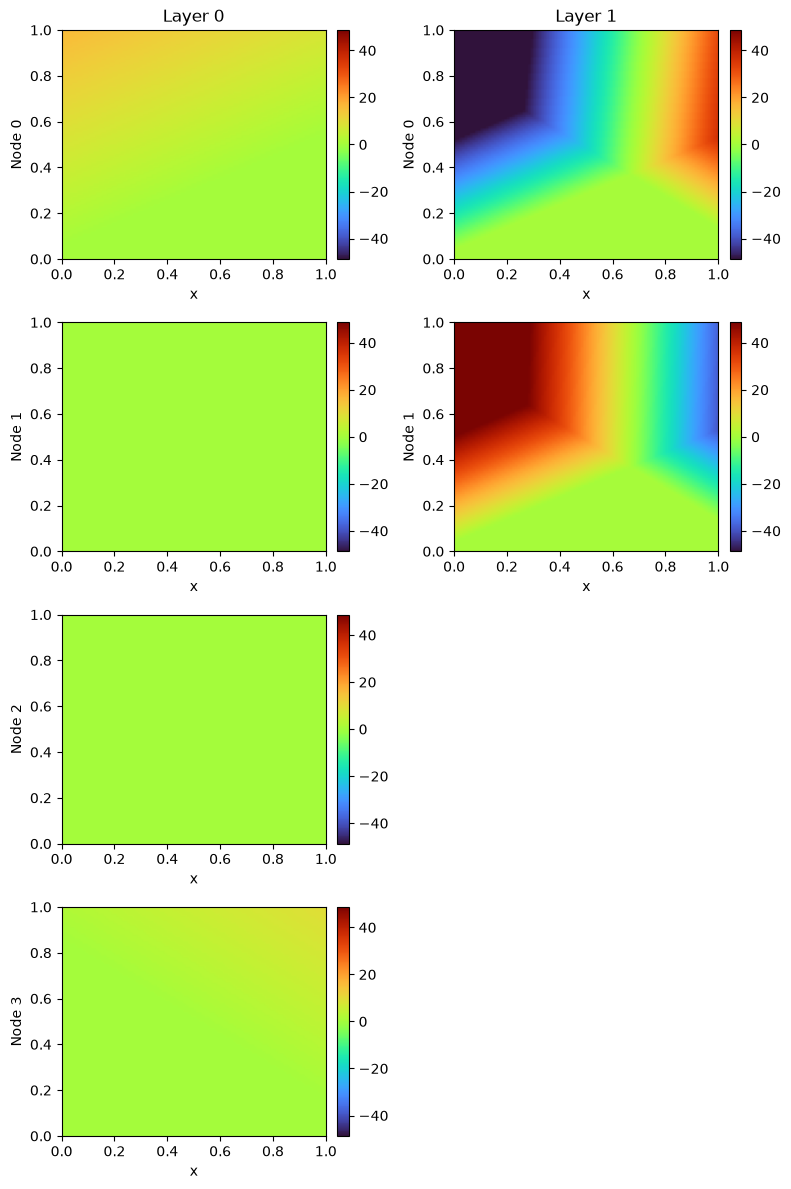

In [11]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [12]:
# Same again but with sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2,4, torch.sigmoid))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))
mse_errors=[]
for i in range(500):
    xor_network.calculate_with_gradient(inputs, outputs, momentum=0.99)

    xor_network.update_weights(0.2)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[1.0000e+00, 6.7073e-08]])
tensor([[1.3559e-07, 1.0000e+00]])
tensor([[4.8241e-05, 9.9995e-01]])
tensor([[9.9996e-01, 4.1498e-05]])


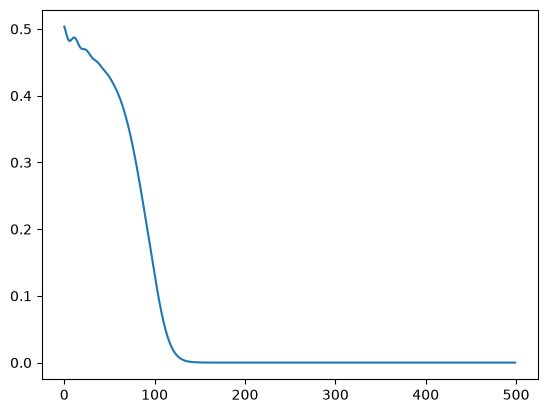

In [13]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

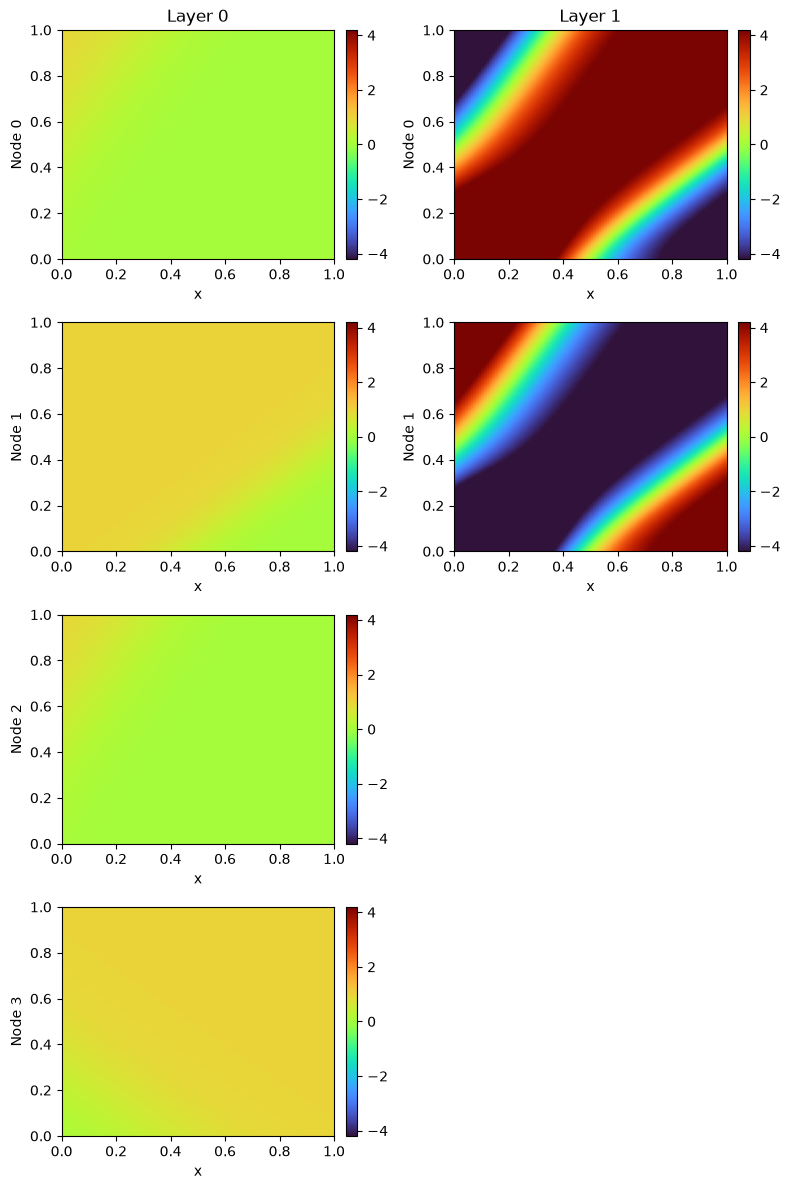

In [14]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=10)

In [15]:
# Gradient descent but with very wide/deep network
xor_network = Network()
xor_network.layers.append(Layer(2,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,2, torch.nn.Identity()))
mse_errors=[]
for i in range(1000):
    xor_network.calculate_with_gradient(inputs, outputs, momentum =0.99)
    xor_network.update_weights(2)
    mse = 0
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[1.0000e+00, 1.2970e-21]])
tensor([[3.4603e-08, 1.0000e+00]])
tensor([[9.8756e-16, 1.0000e+00]])
tensor([[1.0000e+00, 1.2540e-21]])


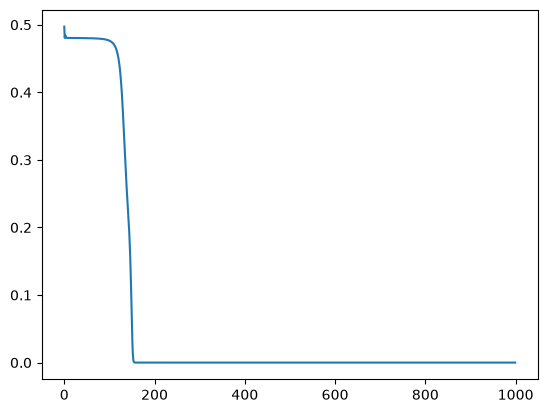

In [16]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 1600x1500 with 37 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 2'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 3'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>, <Axes: >]], dtype=object))

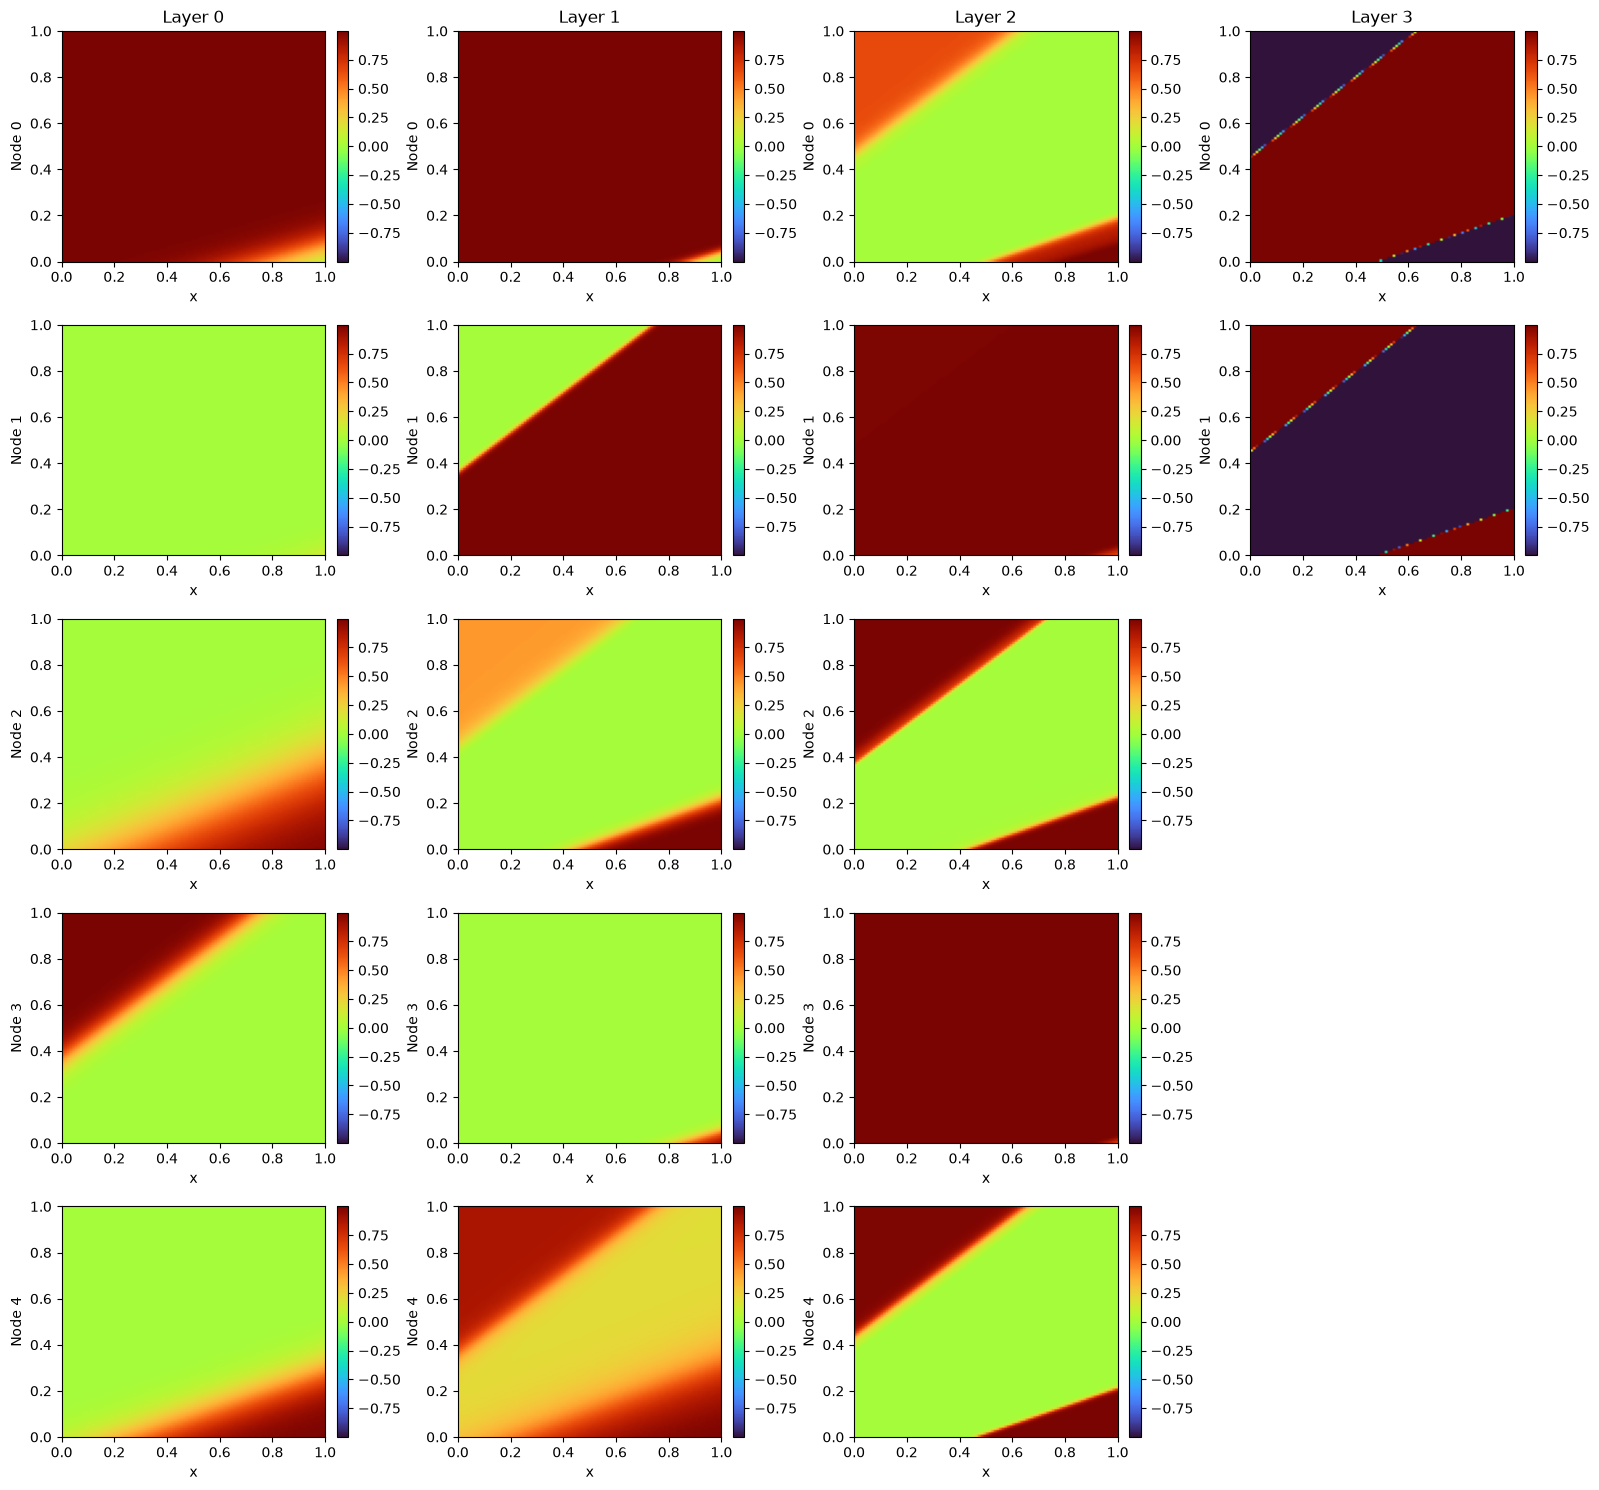

In [17]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=30)